In [1]:
using Pkg
Pkg.activate(".")

  Activating project at `~/Documents/empBAMDP/expt/EmpHCA`


## Loading Relevant Packages

In [2]:
Pkg.instantiate()

Precompiling packages...
   4271.9 ms  ✓ Ghostscript_jll
   4299.0 ms  ✓ CategoricalArrays → CategoricalArraysRecipesBaseExt
   5341.2 ms  ✓ IterativeSolvers
   6908.9 ms  ✓ ARFFFiles
  10057.2 ms  ✓ JSON3
   9047.5 ms  ✓ SciMLBase → SciMLBaseMLStyleExt
  15572.0 ms  ✓ JLD2 → UnPackExt
  16982.8 ms  ✓ CategoricalArrays → CategoricalArraysJSONExt
  17634.6 ms  ✓ BenchmarkTools
  13764.5 ms  ✓ GPUArrays
   2592.6 ms  ✓ Latexify
   1637.1 ms  ✓ OpenML
   1585.8 ms  ✓ GPUArrays → JLD2Ext
   2991.4 ms  ✓ LogDensityProblemsAD → LogDensityProblemsADForwardDiffBenchmarkToolsExt
    573.3 ms  ✓ Latexify → SparseArraysExt
  19747.1 ms  ✓ MLUtils
   8497.7 ms  ✓ Qt6ShaderTools_jll
  11146.3 ms  ✓ Pango_jll
   1589.8 ms  ✓ Qt6Declarative_jll
  27495.0 ms  ✓ MLFlowClient
  20765.7 ms  ✓ ScientificTypes
  10348.7 ms  ✓ MLJLinearModels
   5046.2 ms  ✓ StatisticalMeasuresBase
   1666.9 ms  ✓ CategoricalDistributions
  20741.9 ms  ✓ ReverseDiff
   8916.3 ms  ✓ OptimizationBase → OptimizationMLUtilsExt


In [2]:
using PyPlot
using EmpHCA
using LinearAlgebra
using Random
using Turing, MCMCChains, Distributions
using DataFrames
using CSV
using JLD2
using AdvancedMH
using HypothesisTests

import StatsPlots

PyPlot.svg(true)
rcParams = PyPlot.PyDict(PyPlot.matplotlib."rcParams")
rcParams["svg.fonttype"] = "none"
rcParams["pdf.fonttype"] = 42

42

## Loading behavioral data of Experiment 1

In [3]:
Path_Load = "data/Experiment1/clean/"

# exclusion information
ExcDF = DataFrame(CSV.File(Path_Load * "ExclusionInfo.csv"))
# data of room selection
dataDF = DataFrame(CSV.File(Path_Load * "SelectionData.csv"))
# choosing subject ids of non-excluded participants
subjectIDs = ExcDF.subject[ExcDF.task_outliers .== 0]

dataDF


Row,trial,subject,ID,timeout,rt,room1,room2,action,chosenroom,gold
,Int64,Int64,String31,Bool,Int64,Int64,Int64,Int64,Int64,Float64
1,1,1,0291yns1bxhcl5xhqez3larr,false,4628,10,2,1,2,0.5
2,2,1,0291yns1bxhcl5xhqez3larr,false,5129,4,9,0,4,0.75
3,3,1,0291yns1bxhcl5xhqez3larr,true,-1,5,6,-1,-1,0.75
4,4,1,0291yns1bxhcl5xhqez3larr,false,1894,5,10,0,5,1.25
5,5,1,0291yns1bxhcl5xhqez3larr,false,4234,9,5,1,5,1.75
6,6,1,0291yns1bxhcl5xhqez3larr,false,2816,10,1,1,1,2.25
7,7,1,0291yns1bxhcl5xhqez3larr,false,2013,7,1,0,7,2.625
8,8,1,0291yns1bxhcl5xhqez3larr,false,3013,6,4,1,4,3.25
9,9,1,0291yns1bxhcl5xhqez3larr,false,2402,6,2,0,6,3.58333


Let's look at the data of participant 1:

In [4]:
i_sub = 1
df = dataDF[dataDF.subject .== i_sub, :]
# removing timed-out trials
df = df[df.timeout .== false, :]

Row,trial,subject,ID,timeout,rt,room1,room2,action,chosenroom,gold
,Int64,Int64,String31,Bool,Int64,Int64,Int64,Int64,Int64,Float64
1,1,1,0291yns1bxhcl5xhqez3larr,false,4628,10,2,1,2,0.5
2,2,1,0291yns1bxhcl5xhqez3larr,false,5129,4,9,0,4,0.75
3,4,1,0291yns1bxhcl5xhqez3larr,false,1894,5,10,0,5,1.25
4,5,1,0291yns1bxhcl5xhqez3larr,false,4234,9,5,1,5,1.75
5,6,1,0291yns1bxhcl5xhqez3larr,false,2816,10,1,1,1,2.25
6,7,1,0291yns1bxhcl5xhqez3larr,false,2013,7,1,0,7,2.625
7,8,1,0291yns1bxhcl5xhqez3larr,false,3013,6,4,1,4,3.25
8,9,1,0291yns1bxhcl5xhqez3larr,false,2402,6,2,0,6,3.58333
9,10,1,0291yns1bxhcl5xhqez3larr,false,3765,5,1,1,1,4.08333


In [5]:
# Xinds: pairs of rooms indices shown to the participant 
# see src/Functions_for_gold.jl for the correspondance
Xinds = [[df.room1[i], df.room2[i]] .+ 1 for i = 1:size(df)[1]]
Xinds'

1×130 adjoint(::Vector{Vector{Int64}}) with eltype Adjoint{Int64, Vector{Int64}}:
 adjoint([11, 3])  adjoint([5, 10])  …  adjoint([1, 6])  adjoint([5, 1])

In [6]:
# as: sequence of rooms chosen by the participant
as = df.action .+ 1;
as'

1×130 adjoint(::Vector{Int64}) with eltype Int64:
 2  1  1  2  2  1  2  1  2  1  2  1  2  …  2  1  1  2  2  2  1  1  1  1  1  2

## Loading room information

Information of different rooms to be used for inference

In [7]:
Prooms, ΔState, ΔStateDict = gold_proom_sets();
N_rooms = length(Prooms); Ymax = 1; Xmax = 1;

# transition probabilities for the center node in Room 2
# Prooms[2][a,sp] is the probabilities of going to state sp after taking action a
Prooms[2]

4×9 Matrix{Float64}:
 0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0
 0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0
 0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0

In [8]:
# mapping of sp to physical location
ΔStateDict

Dict{Tuple{Int64, Int64}, Int64} with 9 entries:
  (0, 0)   => 5
  (1, -1)  => 3
  (0, -1)  => 2
  (-1, 0)  => 4
  (0, 1)   => 8
  (1, 1)   => 9
  (-1, -1) => 1
  (-1, 1)  => 7
  (1, 0)   => 6

## Non-hierarchical model-selection

This part perform the inference (for a single subject) corresponding to the generative model described in Methods (Eq. 7).
On a normal computer, the inference takes around 3-5 minutes.

In [9]:
# MCMC sampling hyperparameters
n_chains = 3
chain_lenght = 2500
burn_in_lenght = 500
sample_lenght = 10

# transforming Xinds to the sequence of transition probabilities
Xs = gold_Room2X_indexbased(Prooms, Xinds, ΔState, ΔStateDict, Xmax, Ymax,1)
# transforming Xinds to the sequence of number of actions
Nas = [[size(Prooms[x[1]])[1],size(Prooms[x[2]])[1]] for x = Xinds]

# defining the generative model (see src/Functions_for_goldDataE1.jl)
modelAll = TuringGoldBasicInfvsEmplvsNa(Xs, Xinds, Nas, as; N_rooms = N_rooms, K = 1)
# defining the sampling method for MCMC (see Turing.jl tutorials)
gAll = Gibbs(HMC(0.01, 50, :θ, :l, :β, :βa, :βθ), MH(:m, :γ))
# inference
chnAll = sample(modelAll, gAll,  MCMCThreads(), chain_lenght, n_chains);

┌ Warning: Only a single thread available: MCMC chains are not sampled in parallel
└ @ AbstractMCMC ~/.julia/packages/AbstractMCMC/mcqES/src/sample.jl:432
Sampling (1 thread): 100%|██████████████████████████████| Time: 0:03:53


In [ ]:
# primary plotting the MCMC results
StatsPlots.plot(chnAll; legend=true)

In [11]:
# cleaning up the MCMC samples by accounting for the burn-in length and thinning lenght
chnAll_df = DataFrame(chnAll)
filter!(row -> row.iteration > burn_in_lenght, chnAll_df)
chnAll_df = chnAll_df[1:sample_lenght:size(chnAll_df)[1],:]

Row,iteration,chain,m,βa,l,γ,β,βθ,θ[1],θ[2],θ[3],θ[4],θ[5],θ[6],θ[7],θ[8],θ[9],θ[10],θ[11],θ[12],lp
,Int64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,501,1,3.0,9.19112,3.7147,0.59048,0.26703,6.69951,1.12792,0.482946,1.13907,-0.367346,1.1932,-0.266708,0.552114,0.985199,0.642839,0.269955,0.807559,-1.85011,-103.362
2,511,1,3.0,12.1508,3.98006,0.329424,0.336933,17.059,-2.28198,-0.860884,-0.659516,0.706861,-0.356109,-0.404201,0.892371,1.75103,0.529891,-1.70339,1.40089,-0.142951,-106.195
3,521,1,3.0,10.1299,4.96348,0.290241,0.245186,8.8698,0.00857044,-0.787132,-0.613647,0.516578,-0.93925,0.577253,-0.280648,0.398337,0.854669,0.0419298,0.827188,-0.730469,-100.767
4,531,1,3.0,1.52719,2.84101,0.243899,0.420106,0.645135,-0.279441,0.170609,-0.517603,-1.41127,-1.20608,-0.5089,-0.0118328,-1.11738,0.303079,-0.476997,-0.800286,-0.367688,-104.737
5,541,1,3.0,10.0318,6.31494,0.374054,0.269594,7.66811,-0.461566,0.881171,-1.1155,-0.511071,0.452268,-0.236028,-0.181466,1.31831,-1.15099,0.506775,-0.354919,0.557896,-101.555
6,551,1,3.0,10.2022,2.18524,0.661264,0.314733,1.36722,0.542323,-0.00389577,-0.589938,0.696976,-1.57195,-0.895505,1.2744,0.819908,-2.16807,0.060626,-0.326649,-0.77247,-105.868
7,561,1,3.0,8.0288,3.0672,0.543848,0.286291,2.72774,-0.563723,-0.47488,-0.831549,-0.714595,-0.527133,0.832061,1.26853,1.67475,-2.88851,-1.2043,-1.26954,-1.01719,-108.632
8,571,1,3.0,7.31836,5.57765,0.241445,0.340192,3.60749,-0.284493,-0.955406,-0.74118,-0.547521,-0.800507,-2.32007,0.6896,0.243837,-0.0580989,1.41324,1.50113,0.383423,-104.915
9,581,1,3.0,6.30492,4.85723,0.241445,0.35366,7.96204,-1.26195,-0.260746,-0.413929,0.242069,0.0694585,-1.27002,-0.236787,-0.0651634,-0.443888,-0.0269855,0.791098,1.41131,-101.172


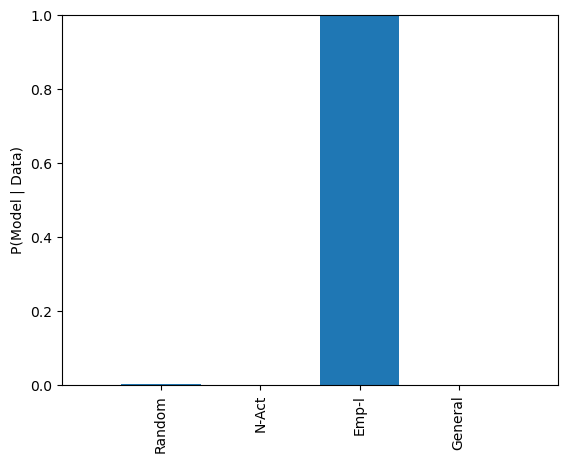

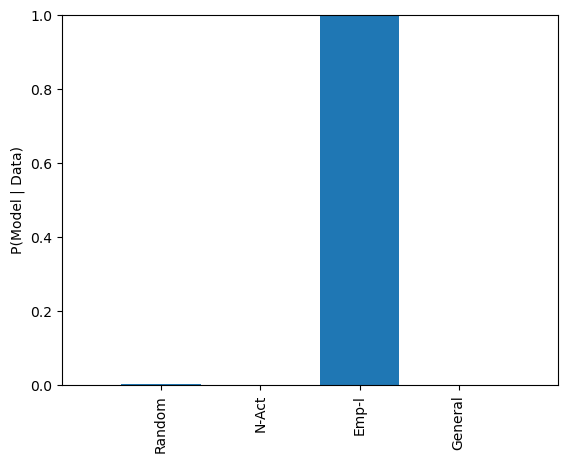

In [12]:
# plotting the processed results
x = 1:4
x_names = ["Random","N-Act","Emp-l","General"]
fig = figure(); ax = subplot(1,1,1)
ax.bar(x,[mean(chnAll_df.m .== i) for i = x])
ax.set_ylim([0,1]); ax.set_xlim([0,x[end]+1]); 
ax.set_xticks(x); ax.set_xticklabels(x_names,rotation = 90)
ax.set_ylabel("P(Model | Data)")
display(fig)